<a href="https://colab.research.google.com/github/Jayesh-m/collage/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree

# ── 1. Load Data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = ['age','sex','cp','trestbps','chol','fbs','restecg',
           'thalach','exang','oldpeak','slope','ca','thal','target']

df = pd.read_csv(url, names=columns, na_values='?')
df.dropna(inplace=True)

df.head()



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
# Binary classification
df['target'] = (df['target'] > 0).astype(int)

X = df.drop('target', axis=1)
y = df['target']

#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# WITHOUT Feature Scaling
dt_no_scale = DecisionTreeClassifier(random_state=42)
dt_no_scale.fit(X_train, y_train)
y_pred_no_scale = dt_no_scale.predict(X_test)

'''
# WITH Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

dt_scaled = DecisionTreeClassifier(random_state=42)
dt_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = dt_scaled.predict(X_test_scaled)
'''
# ── 5. Evaluation
def evaluate(name, y_true, y_pred):
    print(f"\n{'='*45}")
    print(f"  {name}")
    print('='*45)
    print(classification_report(y_true, y_pred,
          target_names=['No Disease', 'Disease']))

evaluate("Without Feature Scaling", y_test, y_pred_no_scale)
#evaluate("With Feature Scaling",    y_test, y_pred_scaled)




  Without Feature Scaling
              precision    recall  f1-score   support

  No Disease       0.87      0.75      0.81        36
     Disease       0.69      0.83      0.75        24

    accuracy                           0.78        60
   macro avg       0.78      0.79      0.78        60
weighted avg       0.80      0.78      0.79        60



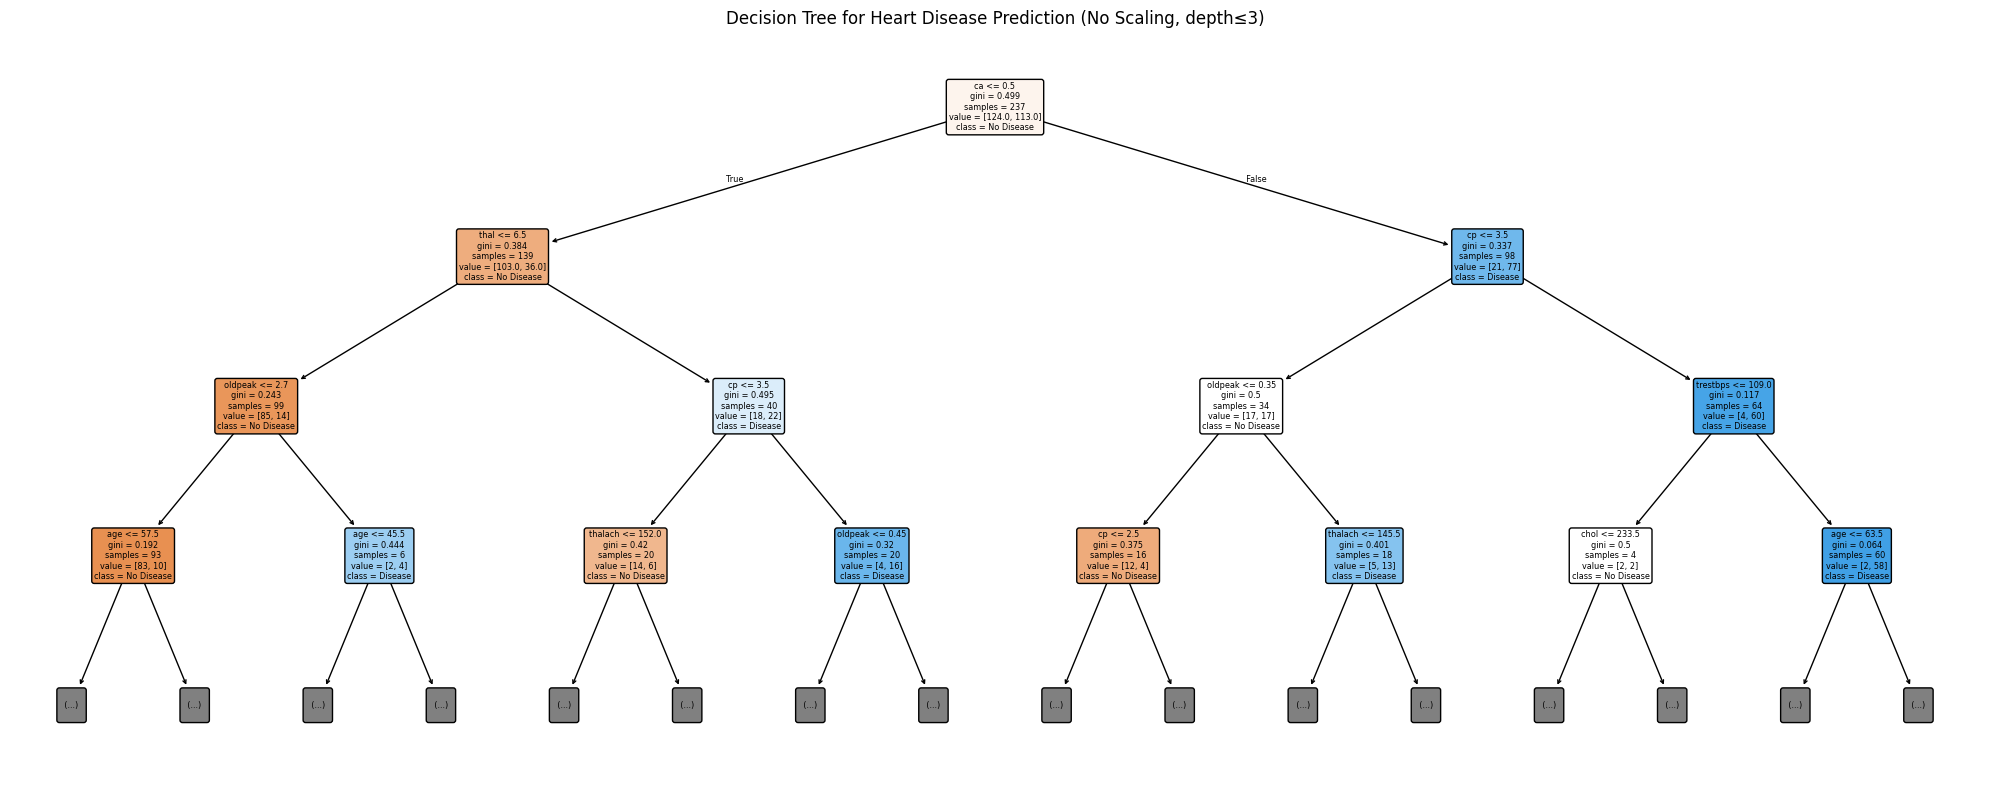

In [ ]:


#Visualise the Tree
plt.figure(figsize=(20, 8))
tree.plot_tree(dt_no_scale, feature_names=X.columns,
               class_names=['No Disease', 'Disease'],
               filled=True, rounded=True, max_depth=3)
plt.title("Decision Tree for Heart Disease Prediction (No Scaling, depth≤3)")
plt.tight_layout()
plt.show()